# Assignment 2: Spotify Reviews Rating Classification
### Deep Learning in NLP with PyTorch & BPE Tokenization

**Objective:** Build an end-to-end Deep Learning sequence model (LSTM) using a modern BPE tokenizer (`tiktoken`) to classify user reviews of the Spotify mobile app into star ratings from **1 to 5**.

**Evaluation Metric:** Macro F1 Score & Multi-class Accuracy
> Macro F1 treats all star ratings (1, 2, 3, 4, 5) equally, ensuring the model performs well across all categories.

---

### Assignment Roadmap:
1. **Load Data**: Stream the dataset from GitHub
2. **EDA**: Check nulls, duplicates, and visualize the class distribution
3. **Train / Test Split**: 80/20 stratified split with shifted labels (`0` to `4`)
4. **Deep Learning Data Prep**:
   - Tokenize text with `tiktoken` BPE (`cl100k_base`)
   - Implement `encode_and_pad` to standardize sequence lengths
   - Create PyTorch `TensorDataset` and `DataLoader`
5. **Build `SpotifyRatingLSTM`**: Embedding $\to$ LSTM $\to$ Linear Head
6. **Training Loop**: Train the model and plot Loss & Accuracy curves
7. **Evaluation**: Classification Report & $5 \times 5$ Confusion Matrix
8. **Inference**: Predict star ratings on custom app reviews
9. **Reflection**: Analysis questions & bonus challenge

## 0. Setup and Imports

In [1]:
# Enable inline plotting for Google Colab and Jupyter
%matplotlib inline

# Install tiktoken if running in Colab
!pip install tiktoken -q

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tiktoken

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

# Plotting aesthetic settings
plt.style.use('default')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Select device (GPU if available, otherwise CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 1. Load the Dataset

The dataset contains over 60,000 real Google Play Store reviews for the Spotify app with columns:
- `Time_submitted`: Timestamp of the review
- `Review`: User text review
- `Rating`: Star rating from 1 to 5

In [2]:
# Load dataset directly from GitHub repository
DATA_URL = 'https://raw.githubusercontent.com/Muhammed-M/iti-summer-training-aug2026/main/NLP/datasets/Spotify-Reviews-Rating.csv'

data = pd.read_csv(DATA_URL)
print(f'Shape: {data.shape}')
data.head()

Shape: (61594, 3)


,Time_submitted,Review,Rating
0,7/9/2022 15:00,"Great music service, the audio is high quality...",5
1,7/9/2022 14:21,Please ignore previous negative rating. This a...,5
2,7/9/2022 13:27,"This pop-up ""Get the best Spotify experience o...",4
3,7/9/2022 13:26,Really buggy and terrible to use as of recently,1
4,7/9/2022 13:20,Dear Spotify why do I get songs that I didn't ...,1


## 2. Exploratory Data Analysis (EDA)

### 2.1 Basic Inspection & Data Cleaning

In [4]:
# TODO 1: Inspect column data types, non-null counts, and memory usage
# Hint: use data.info()

# Your code here:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61594 entries, 0 to 61593
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Time_submitted  61594 non-null  object
 1   Review          61594 non-null  object
 2   Rating          61594 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.4+ MB


In [6]:

# TODO 2: Check for missing reviews and duplicates
# 1. Print the count of null values in 'Review'
# 2. Print the count of duplicate reviews in 'Review'
# 3. Drop nulls and duplicates from 'Review', saving the result in `data_clean`

# data_clean = ...

# print(f'Cleaned dataset shape: {data_clean.shape}')
# TODO 2: Check for missing reviews and duplicates

# 1. Count missing reviews
print("Missing reviews:", data["Review"].isnull().sum())

# 2. Count duplicate reviews
print("Duplicate reviews:", data["Review"].duplicated().sum())

# 3. Remove missing and duplicate reviews
data_clean = data.dropna(subset=["Review"]).drop_duplicates(subset=["Review"]).copy()
print(f"Cleaned dataset shape: {data_clean.shape}")

Missing reviews: 0
Duplicate reviews: 242
Cleaned dataset shape: (61352, 3)


### 2.2 Star Rating Distribution

Rating Counts:
Rating
1    17609
2     7107
3     6874
4     7821
5    21941
Name: count, dtype: int64

Rating Percentages:
Rating
1    28.70
2    11.58
3    11.20
4    12.75
5    35.76
Name: proportion, dtype: float64


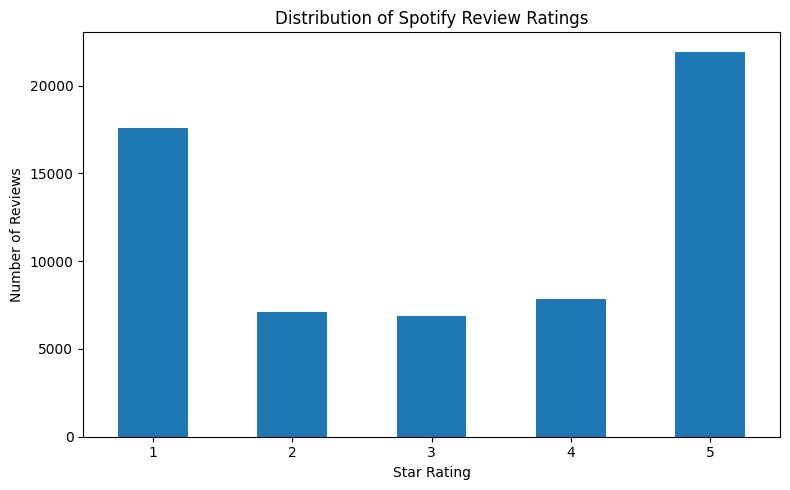

In [7]:
# TODO 3: Analyze and visualize the class distribution
# 1. Calculate value counts and percentages for each Rating (1 to 5)
# 2. Plot a bar chart showing the count of each star rating
# Hint: sns.barplot(...) or data_clean['Rating'].value_counts().plot(kind='bar')

# Your code here:
# 1. Count each rating
rating_counts = data_clean["Rating"].value_counts().sort_index()

# Calculate percentage of each rating
rating_percentages = data_clean["Rating"].value_counts(
    normalize=True
).sort_index() * 100

print("Rating Counts:")
print(rating_counts)

print("\nRating Percentages:")
print(rating_percentages.round(2))

# 2. Plot the rating distribution
plt.figure(figsize=(8, 5))

rating_counts.plot(kind="bar")

plt.title("Distribution of Spotify Review Ratings")
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 3. Train / Test Split

> **Important Note on Labels for PyTorch:**
> PyTorch's `nn.CrossEntropyLoss` expects class indices from **$0$ to $C-1$**.
> Since star ratings are **1 to 5**, shift them by subtracting 1 (`Rating - 1`), so classes are **0, 1, 2, 3, 4**.

In [ ]:
# For smooth, fast training across all machines, we take a balanced sample of 15,000 reviews
SAMPLE_SIZE = 15000
# Keep all cleaned reviews so the model learns from the maximum available data.
# Class imbalance is handled later with weighted CrossEntropyLoss instead of discarding reviews.
df_sample = data_clean.copy()

# TODO 4: Prepare X and y, then perform an 80/20 train/test split
# 1. Extract reviews into X_raw
# 2. Extract shifted ratings (1-5 -> 0-4) into y_raw
# 3. Use train_test_split(..., test_size=0.20, random_state=42, stratify=y_raw)

# X_raw = ...
# y_raw = ...
# X_train, X_test, y_train, y_test = ...

# Print train and test set sizes:
# 1. Extract reviews
X_raw = df_sample["Review"]

# 2. Shift ratings from 1–5 to 0–4
y_raw = df_sample["Rating"] - 1

# 3. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_raw,
    y_raw,
    test_size=0.20,
    random_state=42,
    stratify=y_raw
)

# Print train and test sizes
print("X_train:", len(X_train))
print("X_test:", len(X_test))
print("y_train:", len(y_train))
print("y_test:", len(y_test))

---
## 4. Deep Learning Pipeline: BPE Tokenization & Padding

We use OpenAI's **`tiktoken` (`cl100k_base`)** BPE tokenizer to encode subwords into integer IDs.

In [9]:
# Initialize the BPE Tokenizer (cl100k_base)
tokenizer = tiktoken.get_encoding('cl100k_base')
VOCAB_SIZE = tokenizer.n_vocab
print(f'Vocabulary size: {VOCAB_SIZE:,} subwords')

# Demo on sample review
demo_text = "Spotify is the best app for streaming music and podcasts!"
demo_ids = tokenizer.encode(demo_text)
print(f'Text: "{demo_text}"')
print(f'Tokens: {[tokenizer.decode([t]) for t in demo_ids]}')
print(f'Token IDs: {demo_ids}')

Vocabulary size: 100,277 subwords
Text: "Spotify is the best app for streaming music and podcasts!"
Tokens: ['Sp', 'otify', ' is', ' the', ' best', ' app', ' for', ' streaming', ' music', ' and', ' podcasts', '!']
Token IDs: [6540, 38353, 374, 279, 1888, 917, 369, 17265, 4731, 323, 55346, 0]


### 4.1 Sequence Padding & Truncation

> **Why do we need padding?**
> Reviews have different lengths. To train neural networks in batches, each batch must be a fixed tensor of shape `(batch_size, MAX_LEN)`.
>
> **Your task:** Implement `encode_and_pad(text, tokenizer, max_len)`:
> 1. Clean the text string (e.g. remove HTML tags `<br />`).
> 2. Encode to token IDs with `tokenizer.encode(text)`.
> 3. If length < `max_len`, pad with zeros (`0` = `<PAD>`) at the end.
> 4. If length > `max_len`, truncate to `max_len`.

In [ ]:
MAX_LEN = 150  # maximum sequence length

def encode_and_pad(text, tokenizer, max_len=150):
    """
    TODO 5: Convert raw text string into a list of token IDs
    padded or truncated to max_len.
    """

    # 1. Clean HTML tags / formatting
    text = re.sub(r'<.*?>', ' ', str(text))

    # 2. Tokenize text
    ids = tokenizer.encode(text)

    # 3. Pad or truncate to max_len
    if len(ids) < max_len:
        # Left-pad so the final LSTM hidden state follows real review tokens, not padding.
        ids = [0] * (max_len - len(ids)) + ids
    else:
        ids = ids[-max_len:]

    # 4. Return token IDs
    return ids


# Verify the function
print(
    'Test output (L=8):',
    encode_and_pad('Great app!', tokenizer, max_len=8)
)

In [ ]:
# TODO 6: Encode the dataset and create PyTorch DataLoaders
#
# 1. Encode all reviews in X_train and X_test using encode_and_pad -> X_train_encoded, X_test_encoded
# 2. Convert to torch.tensor(..., dtype=torch.long)
# 3. Create TensorDataset for train and test
# 4. Create DataLoader with BATCH_SIZE = 64 (shuffle=True for train, shuffle=False for test)

BATCH_SIZE = 64

# X_train_encoded = np.array([encode_and_pad(t, tokenizer, MAX_LEN) for t in X_train])
# X_test_encoded  = np.array([encode_and_pad(t, tokenizer, MAX_LEN) for t in X_test])

# train_dataset = TensorDataset(...)
# test_dataset  = TensorDataset(...)

# train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# print(f'Created train_loader ({len(train_loader)} batches) & test_loader ({len(test_loader)} batches)')
# 1. Encode all reviews
X_train_encoded = np.array([
    encode_and_pad(t, tokenizer, MAX_LEN)
    for t in X_train
])

X_test_encoded = np.array([
    encode_and_pad(t, tokenizer, MAX_LEN)
    for t in X_test
])

# 2. Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_encoded, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_encoded, dtype=torch.long)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# 3. Create TensorDataset
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

# 4. Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(
    f"Created train_loader ({len(train_loader)} batches) "
    f"& test_loader ({len(test_loader)} batches)"
)

## 5. Build the LSTM Multi-Class Classifier

The model must classify reviews into **5 classes** (ratings 0 to 4).

**Architecture Components:**
1. **Embedding Layer**: `nn.Embedding(vocab_size, embed_dim, padding_idx=0)`
2. **Sequence Layer**: `nn.LSTM(embed_dim, hidden_dim, batch_first=True)`
3. **Dropout Layer**: `nn.Dropout(dropout)` for regularization
4. **Linear Layer**: `nn.Linear(hidden_dim, num_classes)` (maps the LSTM's final hidden state to 5 class logits)

In [ ]:


class SpotifyRatingLSTM(nn.Module):
    """
    TODO 7: Complete the LSTM Classifier architecture
    """

    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_classes=5, dropout=0.3):
        super().__init__()

        # 1. Embedding layer
        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=0
        )

        # 2. LSTM layer
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        # 3. Dropout and Linear layer
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        # x: (batch_size, seq_len)

        # 1. Embedding
        embeds = self.embedding(x)

        # 2. LSTM
        lstm_out, (h_n, c_n) = self.lstm(embeds)

        # 3. Final hidden state
        final_state = self.dropout(torch.cat((h_n[-2], h_n[-1]), dim=1))

        # 4. Output logits
        logits = self.fc(final_state)

        return logits

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EMBED_DIM = 128
HIDDEN_DIM = 128
NUM_CLASSES = 5

model = SpotifyRatingLSTM(
    VOCAB_SIZE,
    EMBED_DIM,
    HIDDEN_DIM,
    NUM_CLASSES
).to(device)

# Handle the original rating imbalance without deleting majority-class reviews.
from sklearn.utils.class_weight import compute_class_weight
classes = np.arange(5)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train.to_numpy())
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print('Class weights:', class_weights)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

print(model)
print("Device:", device)

## 6. Training the Model

Train the model for **5 to 6 epochs**.

In [ ]:
import torch
import torch.nn as nn
# TODO 9: Write the PyTorch Training Loop
#
# In each epoch:
#   1. Set model.train()
#   2. Loop through train_loader:
#        - Move batch_x, batch_y to device
#        - optimizer.zero_grad()
#        - outputs = model(batch_x)
#        - loss = criterion(outputs, batch_y)
#        - loss.backward()
#        - optimizer.step()
#        - accumulate training loss
#   3. Set model.eval() and evaluate validation accuracy on test_loader with torch.no_grad():
#        - preds = logits.argmax(dim=1)
#        - count correct predictions
#   4. Print epoch loss and test accuracy

EPOCHS = 8
train_losses = []
test_accuracies = []
# TODO 9: Write the PyTorch Training Loop
for epoch in range(EPOCHS):

    # -------------------------
    # 1. Training
    # -------------------------
    model.train()

    total_loss = 0

    for batch_x, batch_y in train_loader:

        # Move data to GPU/CPU device
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(batch_x)

        # Calculate loss
        loss = criterion(outputs, batch_y)

        # Backpropagation
        loss.backward()

        # Stabilize LSTM training by clipping large gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Update weights
        optimizer.step()

        total_loss += loss.item()

    # Average training loss
    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # -------------------------
    # 2. Evaluation on test set
    # -------------------------
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for batch_x, batch_y in test_loader:

            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            outputs = model(batch_x)

            # Get predicted class
            preds = outputs.argmax(dim=1)

            correct += (preds == batch_y).sum().item()
            total += batch_y.size(0)

    test_accuracy = correct / total
    test_accuracies.append(test_accuracy)

    # Print epoch results
    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"- Train Loss: {avg_train_loss:.4f} "
        f"- Test Accuracy: {test_accuracy:.4f}"
    )

# Write your training loop here:


### 6.1 Training Curves (Loss & Accuracy)

In [ ]:
# TODO 10: Plot Training Loss and Test Accuracy Curves
# Use plt.subplot(1, 2, 1) for Train Loss and plt.subplot(1, 2, 2) for Test Accuracy

# Your plotting code here:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Training Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, marker="o")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Test Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(test_accuracies) + 1), test_accuracies, marker="o")
plt.title("Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

## 7. Model Evaluation & Performance Analysis

Compute predictions on the test set and evaluate using **Macro F1 Score**, **Classification Report**, and a **5x5 Confusion Matrix**.

In [ ]:
# TODO 11: Evaluate the model on test_loader
# 1. Collect all predictions and true labels from test_loader
# 2. Remember to shift predictions and true labels back to 1-5 stars (+1)
# 3. Compute accuracy_score and f1_score(..., average='macro')
# 4. Print the classification_report for classes '1 Star' through '5 Stars'

# Your evaluation code here:
from sklearn.metrics import accuracy_score, f1_score, classification_report

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        outputs = model(batch_x)

        preds = outputs.argmax(dim=1)

        all_predictions.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

# Shift labels back from 0–4 to 1–5
true_stars = [x + 1 for x in all_labels]
pred_stars = [x + 1 for x in all_predictions]

# Accuracy
accuracy = accuracy_score(true_stars, pred_stars)

# Macro F1
macro_f1 = f1_score(
    true_stars,
    pred_stars,
    average="macro"
)

print("Test Accuracy:", accuracy)
print("Macro F1 Score:", macro_f1)

# Classification report
print(
    classification_report(
        true_stars,
        pred_stars,
        target_names=[
            "1 Star",
            "2 Stars",
            "3 Stars",
            "4 Stars",
            "5 Stars"
        ]
    )
)

In [ ]:
# TODO 12: Plot the 5x5 Confusion Matrix as a heatmap using seaborn
# 1. Compute confusion_matrix(y_true_stars, y_pred_stars)
# 2. Plot with sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
# 3. Label the axes ('Predicted Rating' vs 'True Rating')

# Your confusion matrix plot code here:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    true_stars,
    pred_stars
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    xticklabels=[1, 2, 3, 4, 5],
    yticklabels=[1, 2, 3, 4, 5]
)

plt.title("Confusion Matrix - Spotify Rating LSTM")
plt.xlabel("Predicted Rating")
plt.ylabel("True Rating")

plt.show()

## 8. Interactive Prediction on Custom App Reviews

Write a helper function to test the trained model on raw user sentences:

In [ ]:
# TODO 13: Complete the predict_rating function
# 1. Set model.eval()
# 2. Encode and pad the input review_text using encode_and_pad
# 3. Convert to a tensor on device
# 4. Run model forward pass inside torch.no_grad()
# 5. Apply softmax to get probabilities: torch.softmax(logits, dim=1)
# 6. Find predicted class (argmax + 1)

def predict_rating(review_text):
    # 1. Evaluation mode
    model.eval()

    # 2. Encode and pad the review
    encoded = encode_and_pad(
        review_text,
        tokenizer,
        MAX_LEN
    )

    # 3. Convert to tensor and add batch dimension
    x = torch.tensor(
        encoded,
        dtype=torch.long
    ).unsqueeze(0).to(device)

    # 4. Forward pass
    with torch.no_grad():
        logits = model(x)

        # 5. Convert logits to probabilities
        probabilities = torch.softmax(logits, dim=1)

        # 6. Get predicted class and convert 0–4 back to 1–5
        predicted_class = torch.argmax(probabilities, dim=1).item()
        predicted_rating = predicted_class + 1

    print("Predicted rating:", predicted_rating)
    print("Probabilities:", probabilities.cpu().numpy())

    return predicted_rating    # Your code here:
    pass

# Test your function on these sample reviews:
# predict_rating('The best music app ever! Great sound quality, love the playlists.')
# predict_rating('Too many ads and crashes constantly after the latest update. Terrible!')
# predict_rating('Good app overall, but missing some podcast features and playback freezes occasionally.')
